In [1]:
%run ../../../../Script/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

Read data and make SDA tables. Either read the separate datasets and concatenate them, or read the data concatenated as a whole.

In [4]:
NUCLEI = sc.read('../../nuclei_analysis/write/NUCLEI.flt.sct.3.h5ad')

Only considering the two last: ['.3', '.h5ad'].
Only considering the two last: ['.3', '.h5ad'].


In [5]:
CELL = sc.read('../../cells_analysis/write/CELLS.norm.3.h5ad')

Only considering the two last: ['.3', '.h5ad'].
Only considering the two last: ['.3', '.h5ad'].


In [6]:
NUCLEI.X = NUCLEI.layers['SCT_counts'].copy()
sc.pp.scale(NUCLEI)

In [7]:
CELL.X = CELL.layers['SCT_counts'].copy()
sc.pp.scale(CELL)

In [8]:
names = np.intersect1d(CELL.var_names, NUCLEI.var_names)
CELL = CELL[:,names].copy()
NUCLEI = NUCLEI[:,names].copy()

In [9]:
NUCLEI_SUB = sc.pp.subsample(NUCLEI, n_obs=CELL.shape[0], random_state=123, copy=True)

In [10]:
NUCLEI_SUB

AnnData object with n_obs × n_vars = 2364 × 23768
    obs: 'spl_prop', 'uns_prop', 'perc_rp', 'perc_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'perc_PRM1', 'perc_PRM2', 'perc_TNP1', 'genes_threshold_filter', 'SDO_outliers', 'SDO_outlyingness', 'all_filters', 'doublet_score', 'predicted_doublet', 'n_counts', 'S_score', 'G2M_score', 'phase', 'SpermatogoniaA_score', 'SpermatogoniaB_score', 'SpermatocytesI_score', 'SpermatocytesII_score', 'Round.Spt_score', 'Elong.Spt_score', 'Sertoli_score', 'Macroph_score', 'Endothelial_score', 'Perit_Myoid_score', 'Smooth_Muscle_score', 'Leptotene_score', 'Zygotene_score', 'Pachytene_score', 'Diplotene_score', 'leiden_R1', 'leiden_R.5', 'leiden_R.25', 'leiden_R.1', 'spermatogenesis_single'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'tot

Make dataframes and concatenate. You can eventually only choose HVGs ore keep all the genes as I did

In [11]:
dfCELL = pd.DataFrame(CELL.X, 
                        index=CELL.obs_names,
                        columns=CELL.var_names)
dfNUCLEI = pd.DataFrame(NUCLEI_SUB.X, 
                        index=NUCLEI_SUB.obs_names,
                        columns=NUCLEI_SUB.var_names)

In [12]:
dfDATA = pd.concat([dfCELL,dfNUCLEI])

export data and cells barcodes

In [13]:
dfDATA.shape

(4728, 23768)

In [14]:
dfDATA.to_csv('./CELLSNUCLEI_tensor.csv' ,
            index=False, header=False, sep=' ')

Now you need to run the script for sda `sdaWorkflow.py` with `gwf`. You need to write by hand the number of cells in the script. It is highlighted by a comment.

In [13]:
#!gwf -b slurm -f sdaWorkflow.py run ALLDATA_scaled_onematrix_data

Analysis Example on one component - we need three matrices where one indicates the significance of a component for one of the two types of data: single cells or single nuclei

In [23]:
adata = ad.AnnData.concatenate(CELL, NUCLEI)

In [24]:
adata.obs.columns

Index(['spl_prop', 'uns_prop', 'perc_rp', 'perc_mito', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'perc_PRM1', 'perc_PRM2', 'perc_TNP1', 'genes_threshold_filter',
       'SDO_outliers', 'SDO_outlyingness', 'all_filters', 'doublet_score',
       'predicted_doublet', 'n_counts', 'S_score', 'G2M_score', 'phase',
       'SpermatogoniaA_score', 'SpermatogoniaB_score', 'SpermatocytesI_score',
       'SpermatocytesII_score', 'Round.Spt_score', 'Elong.Spt_score',
       'Sertoli_score', 'Macroph_score', 'Endothelial_score',
       'Perit_Myoid_score', 'Smooth_Muscle_score', 'Leptotene_score',
       'Zygotene_score', 'Pachytene_score', 'Diplotene_score', 'leiden_R1',
       'leiden_R.5', 'leiden_R.25', 'leiden_R.1', 'spermatogenesis_single',
       'batch'],
      dtype='object')

In [25]:
adata.obs['genes_threshold_filter']

AAACCCACACATTCGA-0    False
AAACCCAGTCTAGGCC-0    False
AAACGAAAGATGATTG-0    False
AAACGCTAGCTTAGTC-0    False
AAACGCTCAGTACTAC-0    False
                      ...  
TTTGTTGCAGCAGATG-1    False
TTTGTTGCATTGCAAC-1    False
TTTGTTGGTCCAGCAC-1    False
TTTGTTGTCGTACACA-1    False
TTTGTTGTCTGGCCGA-1    False
Name: genes_threshold_filter, Length: 11381, dtype: category
Categories (2, object): [False, True]

In [26]:
adata.obs = adata.obs.drop(columns=['genes_threshold_filter','SDO_outliers',
       'SDO_outlyingness'])

In [27]:
A_tot = pd.read_csv('./CELLSNUCLEI_tensor_50comps/it2000/A', sep=' ', header=None)
#B_tot is only for multi-tissues tensor
B_tot = pd.read_csv('./CELLSNUCLEI_tensor_50comps/it2000/B1', sep=' ', header=None)
X_tot = pd.read_csv('./CELLSNUCLEI_tensor_50comps/it2000/X1', sep=' ', header=None)

$B_{tot}$ contains the score for each tissue, telling which component fits to which tissue. Here the sign of the score will influence the loading sign in terms of over expression or underexpression in matrix $X_{tot}$

In [28]:
B_tot

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.355352,5.029290e-01,1.196470,-0.003989,0.000170,0.006063,-0.027480,-0.707754,-0.002224,-1.521740,...,0.744237,-0.001453,1.625040,0.010744,2.540310,-1.103590,-0.016811,-1.787010,-1.356160,-0.004903
1,0.000002,7.027630e-08,-0.001187,0.473372,0.224503,0.709157,0.898205,0.000001,-0.346983,0.043281,...,0.000019,0.374219,0.006739,-1.348690,-0.130598,0.024375,0.748944,-0.051306,0.000003,-0.356366


In [29]:
B_tot.T

,0,1
0,-0.355352,1.538470e-06
1,0.502929,7.027630e-08
2,1.196470,-1.186720e-03
3,-0.003989,4.733720e-01
4,0.000170,2.245030e-01
5,0.006063,7.091570e-01
6,-0.027480,8.982050e-01
7,-0.707754,1.149470e-06
8,-0.002224,-3.469830e-01
9,-1.521740,4.328090e-02


We can see mostly that each component pertains to only cells or nuclei.

In [30]:
B_tot2 = pd.DataFrame( np.hstack(np.array(B_tot)), columns=['score'])
B_tot2['component'] = np.concatenate((np.arange(50),np.arange(50)))
B_tot2['condition'] = np.concatenate((np.array(['cells'] * 50),np.array(['nuclei'] * 50)))

<Axes: xlabel='component', ylabel='score'>

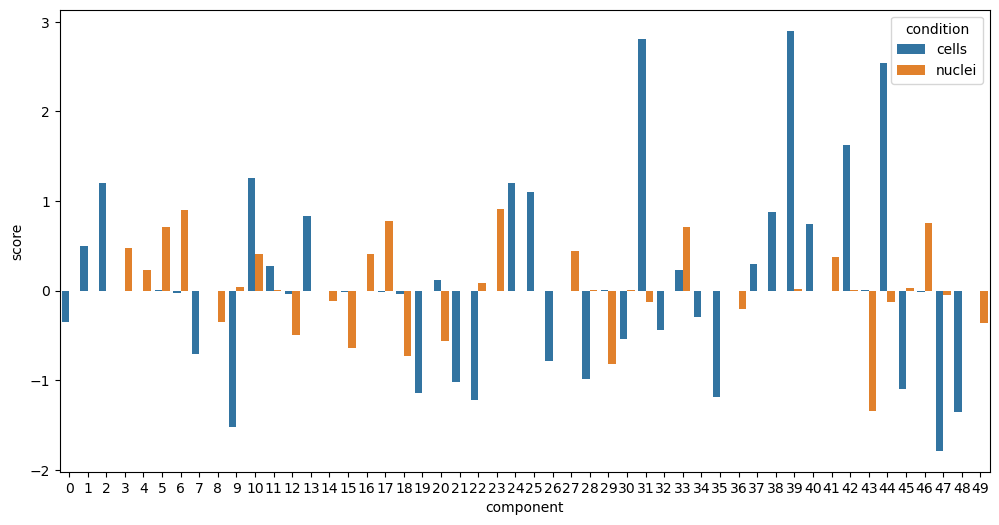

In [31]:
plt.figure(figsize=(12, 6))
sns.barplot(data=B_tot2, x='component', y='score', hue='condition', )

$A_{tot}$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. Note that this score has to be multiplied by the one in the matrix $B_{tot}$, which changes also the sign. We do it already here and we keep track of which condition we have to refer to

In [32]:
A_tot.shape

(2364, 50)

In [33]:
A_tot.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.197336,0.853247,1.011270,-0.949878,-0.364968,-0.221031,1.070030,-0.695469,-1.912700,-0.376792,...,-0.162710,-1.794840,-0.322663,0.062294,-0.005752,-0.336959,0.174575,1.172420,-0.048747,0.480047
1,-0.119121,1.424650,0.953795,0.221078,1.098330,1.550650,0.627560,-0.674125,0.525846,2.723920,...,0.282166,0.305524,0.254773,0.066751,-1.170450,-0.387640,-0.594654,0.265930,0.847583,-0.200159
2,-0.098326,1.462320,1.278440,-0.249018,0.971807,1.455530,1.027270,-0.874044,0.791120,-0.934166,...,-0.022408,0.548234,0.031268,0.456240,-0.539566,-0.476738,-0.531717,1.239950,-0.230454,-0.289494
3,-0.198045,-1.886420,1.098990,0.195948,-0.169525,-0.504649,0.086783,-0.782815,-0.174018,1.147970,...,0.298823,0.272196,0.196773,-0.319361,1.374220,-0.467062,-1.150300,0.375218,-0.031995,0.244655
4,-1.054320,0.118810,0.201102,-1.197460,1.082700,-4.629270,-3.084120,1.692370,1.318880,-0.422202,...,-0.078749,-0.904595,-0.761415,-0.166945,-0.351469,0.124008,0.699937,0.556414,-0.256595,0.866673


In [34]:
A_tot2 = A_tot.copy()

In [35]:
refer_condition = list()
conds = {0:'CELLS',1:'NUCLEI'}

In [36]:
for i in np.arange(50):
    max_idx = np.argmax(np.abs(B_tot.iloc[:,i]))
    refer_condition.append(conds[max_idx])
    A_tot2.iloc[:,i] = A_tot.iloc[:,i] * B_tot.iloc[max_idx,i]

Not all components will have high values as a result of the product with the cells-nuclei matrix $B_{tot}$. We can see it in the plot below

<Axes: xlabel='components', ylabel='score'>

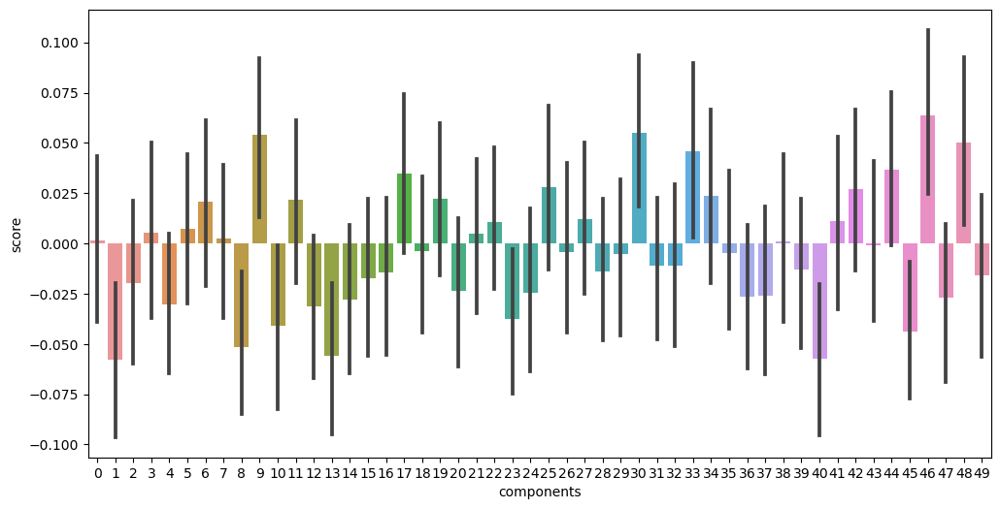

In [37]:
A_tot2_plot = pd.DataFrame( np.hstack(np.array(A_tot2)), columns=['score'])
components = np.repeat(0,2364)
for i in np.arange(1,50):
    components = np.concatenate( (components, np.repeat(i,2364)) )
A_tot2_plot['components'] = components
plt.figure(figsize=(12, 6))
sns.barplot( data=A_tot2_plot, x='components', y='score' )

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [38]:
X_tot.columns = adata.var_names

In [39]:
X_tot.shape

(50, 23768)

In [40]:
X_tot.head()

,A1BG,A1CF,A2M,A2ML1,A3GALT2,AAAS,AACS,AADAC,AADACL2,AADACL4,...,amplicon-chrY-LOC112208622-3,amplicon-chrY-LOC745154-12,amplicon-chrY-LOC745154-17,amplicon-chrY-LOC745154-4,amplicon-chrY-LOC749973-125,amplicon-chrY-LOC749973-27,amplicon-chrY-LOC749973-28,amplicon-chrY-LOC749973-32,amplicon-chrY-LOC749973-37,amplicon-chrY-LOC749973-43
0,0.018418,0.000792,-0.167310,0.361480,-0.059976,-0.000031,0.003103,0.000658,0.001118,0.008092,...,0.000332,-0.000039,-0.001206,0.000423,0.001385,-0.000111,0.000128,0.000716,0.000777,0.000482
1,0.007548,-0.003156,0.003431,0.000261,0.001287,0.056701,-0.001441,-0.157044,0.001945,0.000128,...,0.002359,0.002104,-0.001956,-0.039239,0.001947,0.024519,-0.000243,0.018665,0.177377,-0.083456
2,0.000003,0.000131,-0.000080,0.002255,-0.083459,0.000146,0.000070,-0.000064,0.001178,0.000095,...,-0.000229,0.000262,-0.000080,0.000048,0.001185,0.000011,0.000015,0.000679,0.001056,0.000095
3,-0.000080,-0.000201,-0.000009,0.194830,0.000922,-0.001450,-0.000842,-0.001631,0.029718,0.000044,...,-0.000695,-0.021713,-0.000013,0.000519,0.014458,-0.000307,-0.000015,0.001624,0.003229,0.000073
4,-0.002758,-0.007601,-0.124882,-0.001123,0.007727,0.017144,0.015092,-0.014263,0.004968,-0.000946,...,-0.005221,0.156598,-0.000732,-0.000788,0.003649,0.007682,-0.000249,0.000408,-0.001166,0.320221


<Axes: xlabel='PRM2', ylabel='Count'>

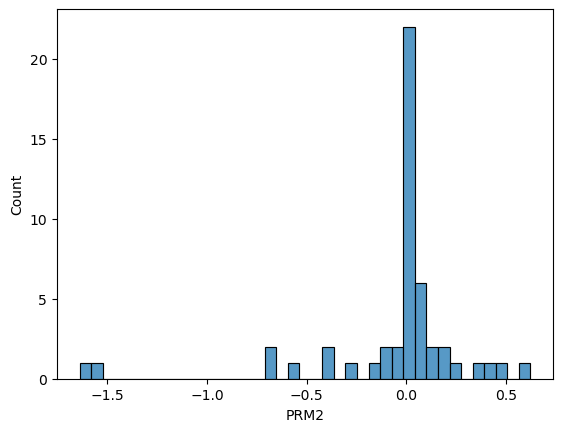

In [41]:
sns.histplot(X_tot['PRM2'])

## Calculate already some stuff to save it in the annotated data object

All components' cell scores 

In [42]:
cells_names = dfCELL.index
nuc_names = dfNUCLEI.index

In [43]:
cells_names_2 = [i+"-0" for i in cells_names]
nuc_names_2 = [i+"-1" for i in nuc_names]

obs_names = np.concatenate( (cells_names_2, nuc_names_2), dtype='str' )

In [44]:
adata_sub = adata[obs_names,:].copy()

In [45]:
for i in range(X_tot.shape[0]):
    if(refer_condition[i]=='CELLS'):
        cells_scores = np.asarray(A_tot2.iloc[:,i])
        nuc_scores = np.repeat(0, 2364)
    if(refer_condition[i]=='NUCLEI'):
        cells_scores = np.repeat(0, 2364)
        nuc_scores = np.asarray(A_tot2.iloc[:,i])
    adata_sub.obs['SDA_cellscore_C'+str(i)] = np.concatenate( (cells_scores, nuc_scores), dtype='float16' )

All components' significant cells. I chose threshold based on different runs of SDA and looking at how scores looked like in plots. For each component a cell will be irrelevant, negative or positive based on score thresholds.

<Axes: xlabel='SDA_cellscore_C1', ylabel='Count'>

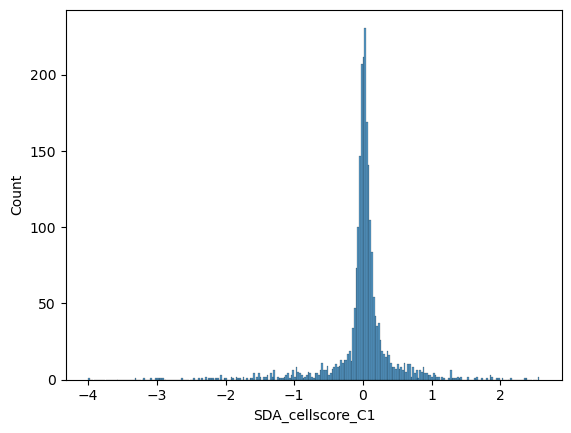

In [46]:
sns.histplot(adata_sub.obs['SDA_cellscore_C1'][adata_sub.obs['SDA_cellscore_C1']!=0] )

In [47]:
#A_tot2.index = adata_sub.obs_names
for i,j in zip( range(X_tot.shape[0]), refer_condition):
    #choose or automatize a threshold
    #score_neg = min(-1, np.quantile(A[i], .1))
    #score_pos = max(+1, np.quantile(A[i], .9))
    score_neg = -.25
    score_pos = +.25
    cells_pos = np.array( A_tot2[i][ A_tot2[i]>score_pos ].index )
    cells_neg = np.array( A_tot2[i][ A_tot2[i]<score_neg ].index )
    assign_scores = np.array(['IRRELEVANT']*adata_sub.shape[0], dtype='str')
    batch_scores = ['POSITIVE' if i in cells_pos 
         else 'NEGATIVE' if i in cells_neg
         else 'IRRELEVANT'
         for i in np.arange(2364)]
    if(j=='CELLS'):
        assign_scores[0:2364] = batch_scores
    if(j=='NUCLEI'):
        assign_scores[2364:4728] = batch_scores    
    adata_sub.obs['sda_cell_relevant_C'+str(i)] = pd.Categorical(assign_scores)

In [48]:
adata_sub.obs['sda_cell_relevant_C0'].value_counts()

IRRELEVANT    3918
NEGATIVE       438
POSITIVE       372
Name: sda_cell_relevant_C0, dtype: int64

All components' significant genes. Significant genes for positive and negative components are saved with a boolean vector in the .var storage of the adata object. Relevant genes are saved with a relaxed and strict threshold (high and low in the name). 

<Axes: xlabel='2', ylabel='Count'>

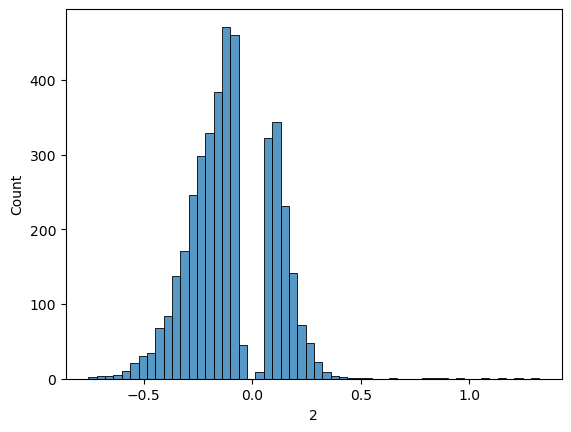

In [49]:
jj=2; sns.histplot(X_tot.T.iloc[:,jj][np.abs(X_tot.T.iloc[:,jj])>0.05])

In [50]:
for i in range(X_tot.shape[0]):
    scores = pd.Series( X_tot.T.iloc[:,i], index=adata.var_names )
    neg_score = np.quantile(scores, .005)
    pos_score = np.quantile(scores, .995)
    component_pos = X_tot.T[i][ X_tot.T[i]>pos_score].index
    component_neg = X_tot.T[i][ X_tot.T[i]<neg_score].index
    adata_sub.var['sda_pos_high_C'+str(i)] = [i in component_pos for i in adata_sub.var_names]
    adata_sub.var['sda_neg_high_C'+str(i)] = [i in component_neg for i in adata_sub.var_names]
    neg_score = np.quantile(scores, .005)
    pos_score = np.quantile(scores, .995)
    component_pos = X_tot.T[i][ X_tot.T[i]>pos_score].index
    component_neg = X_tot.T[i][ X_tot.T[i]<neg_score].index
    adata_sub.var['sda_pos_low_C'+str(i)] = [i in component_pos for i in adata_sub.var_names]
    adata_sub.var['sda_neg_low_C'+str(i)] = [i in component_neg for i in adata_sub.var_names]

In [51]:
np.array( adata_sub.var['sda_pos_low_C0'][adata_sub.var['sda_pos_low_C0']].index )

array(['ACRBP', 'ACTL7A', 'ACTL7B', 'ACTL9', 'ACTRT2', 'ACTRT3', 'ADCK2',
       'AKAP4', 'ARMC12', 'BAG5', 'BRINP3', 'C20H20orf85', 'C2BH2orf57',
       'C5H5orf49', 'C6H6orf118', 'CABS1', 'CABYR', 'CALCOCO2', 'CALR3',
       'CAPZA3', 'CCDC102B', 'CCDC54', 'CCIN', 'CDKN3', 'CDV3', 'CRISP2',
       'CXXC5', 'CYLC2', 'DCST1', 'DCST2', 'DDI1', 'DEUP1', 'DKKL1',
       'DNAJB8', 'DST', 'DUSP13', 'DYNLRB2', 'FAIM2', 'FAM71B', 'FAM78A',
       'FGL1', 'FNDC11', 'FSCB', 'FTMT', 'GAPDHS', 'GLUL', 'GOT1L1',
       'GPR135', 'GSG1', 'GSTM3', 'GTSF1L', 'H1FNT', 'HMGB4', 'IL13RA2',
       'IQCE', 'IRGC', 'KEF41-p11', 'KISS1', 'LAPTM4A', 'LELP1',
       'LOC100608238', 'LOC100609451', 'LOC100610176', 'LOC100610772',
       'LOC101057544', 'LOC104002022', 'LOC104006293', 'LOC107973852',
       'LOC107974455', 'LOC107975155', 'LOC112206709', 'LOC473574',
       'LOC736083', 'LOC736599', 'LOC739572', 'LOC743463', 'LOC745816',
       'LRRC39', 'MED21', 'MS4A5', 'MTRNR2L14', 'MYO5C', 'NKX6-1', 'OAZ3',

In [52]:
np.array( adata_sub.var['sda_neg_low_C0'][adata_sub.var['sda_neg_low_C0']].index )

array(['ACYP2', 'AFF1', 'AGAP11', 'AGPAT4', 'AKT3', 'ANO4', 'ARHGAP32',
       'ARHGEF18', 'BIN3', 'BTBD9', 'BTRC', 'C16H16orf97', 'CCNY',
       'CEP128', 'COL22A1', 'CPLX1', 'CSNK1G1', 'CUX2', 'DENND1A',
       'EGFLAM', 'EHBP1', 'ENPP4', 'EPHA5', 'FAM135B', 'FAM168A',
       'FAXDC2', 'FER', 'FRRS1L', 'GIGYF2', 'GRAMD1C', 'GRM8', 'HERC4',
       'HIPK2', 'IL15RA', 'KCNIP4', 'KIAA1614', 'KIFAP3', 'LOC100610757',
       'LOC100611737', 'LOC100612601', 'LOC101056900', 'LOC101057999',
       'LOC101059134', 'LOC104001367', 'LOC104001854', 'LOC104002402',
       'LOC104003202', 'LOC104003352', 'LOC104006020', 'LOC104006141',
       'LOC104006346', 'LOC104006617', 'LOC107966694', 'LOC107966698',
       'LOC107966963', 'LOC107967060', 'LOC107967235', 'LOC107967589',
       'LOC107967785', 'LOC107967950', 'LOC107968218', 'LOC107968525',
       'LOC107968537', 'LOC107968631', 'LOC107969147', 'LOC107969458',
       'LOC107969519', 'LOC107969794', 'LOC107970278', 'LOC107970548',
       'LOC107

In [53]:
adata_sub.obs['sda_cell_relevant_C41']

AAACCCACACATTCGA-0    IRRELEVANT
AAACCCAGTCTAGGCC-0    IRRELEVANT
AAACGAAAGATGATTG-0    IRRELEVANT
AAACGCTAGCTTAGTC-0    IRRELEVANT
AAACGCTCAGTACTAC-0    IRRELEVANT
                         ...    
TCTCACGTCCATTTGT-1      NEGATIVE
TAAGCGTCACTAAACC-1    IRRELEVANT
GTAGTACCAAACTAGA-1      POSITIVE
AGGTCATAGGACAAGA-1      POSITIVE
ATTCCCGTCATGAGTC-1      POSITIVE
Name: sda_cell_relevant_C41, Length: 4728, dtype: category
Categories (3, object): ['IRRELEVANT', 'NEGATIVE', 'POSITIVE']

In [55]:
adata_sub.write('./SDA_object_sub.h5ad')

In [73]:
adata_sub = sc.read('./SDA_object_sub.h5ad')

In [74]:
adata_to_ingest = sc.read('../write/adata.dpt.h5ad')

In [75]:
cells_to_ingest = adata_to_ingest[adata_to_ingest.obs['batch']=='Cells'].copy()
nuclei_to_ingest = adata_to_ingest[adata_to_ingest.obs['batch']=='Nuclei'].copy()

In [76]:
adata_sub = adata_sub[adata_sub.obs['batch']=='1']

In [78]:
sc.pp.neighbors(adata_sub)
sc.pp.pca(adata_sub)
sc.tl.umap(adata_sub)
cells_to_ingest.var_names = adata_sub.var_names
nuclei_to_ingest.var_names = adata_sub.var_names
sc.pp.neighbors(cells_to_ingest)
sc.pp.neighbors(nuclei_to_ingest)

In [84]:
sc.tl.umap(cells_to_ingest)
sc.tl.umap(nuclei_to_ingest)

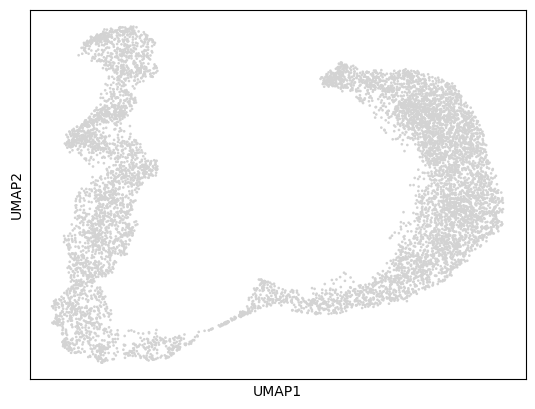

In [85]:
sc.pl.umap(nuclei_to_ingest)

In [88]:
nuclei_to_ingest.X = nuclei_to_ingest.layers['raw_counts'].copy()

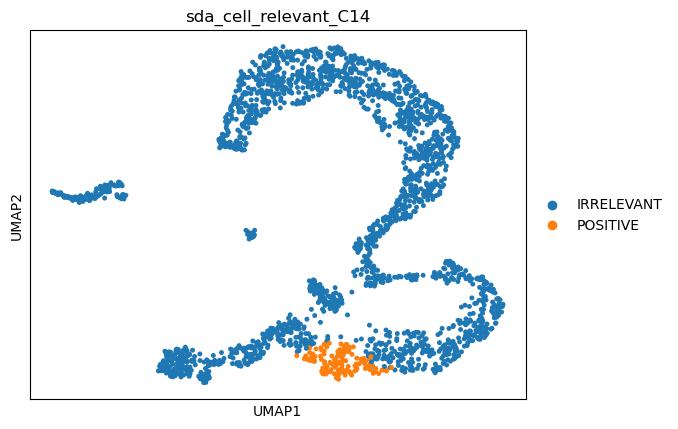

In [106]:
sc.pl.umap(adata_sub, color='sda_cell_relevant_C14')

In [97]:
obs_to_ingest = [f'sda_cell_relevant_C{i}' for i in np.arange(50)]

sc.tl.ingest(nuclei_to_ingest, adata_sub, obs=obs_to_ingest)

In [103]:
sc.tl.umap(nuclei_to_ingest)

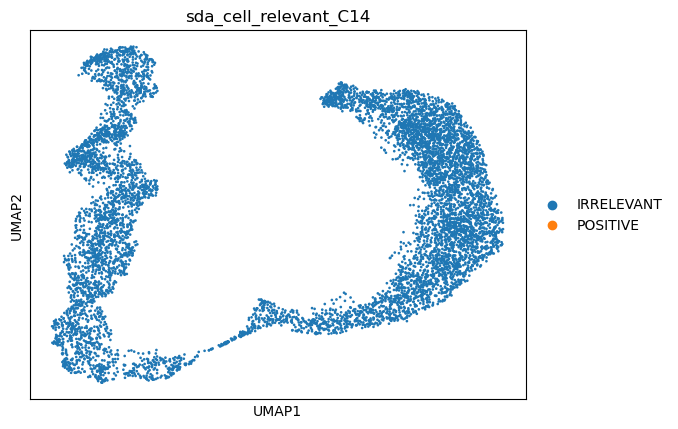

In [107]:
sc.pl.umap(nuclei_to_ingest, color='sda_cell_relevant_C14')

In [32]:
adata_full = sc.read('../write/adata.dpt.h5ad')

In [37]:
adata_full.obs['sda_cell_relevant_C3'] = adata.obs['sda_cell_relevant_C3']

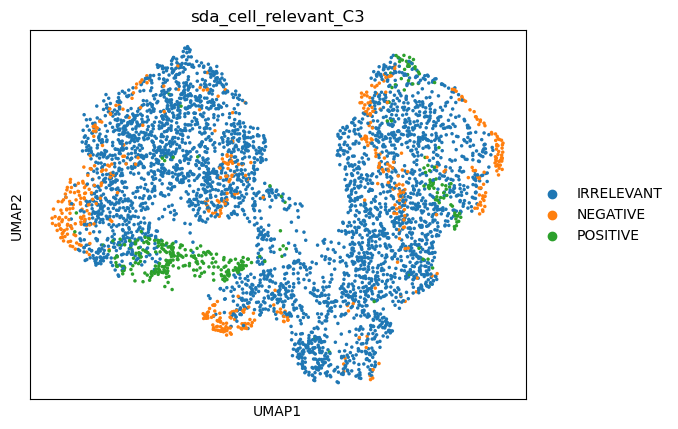

In [45]:
sc.pl.umap(adata_sub, color='sda_cell_relevant_C3')

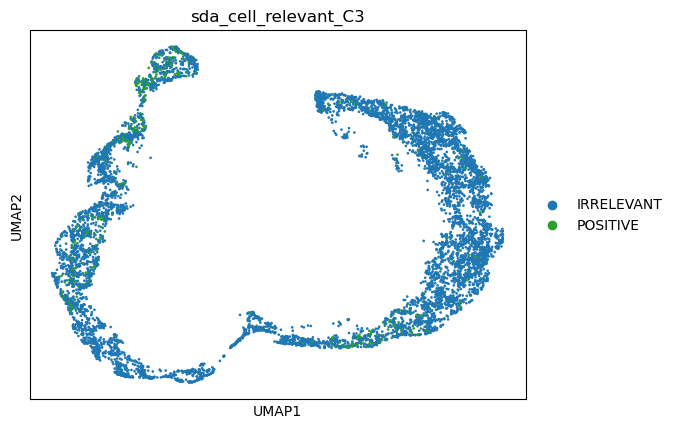

In [44]:
sc.pl.umap(adata_full[adata_full.obs['batch']=='Nuclei'], color='sda_cell_relevant_C3')

In [42]:
adata_full.obs.head()

,spl_prop,uns_prop,perc_rp,perc_mito,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,spermatogenesis_single,batch,spermatogenesis_single_compact,spermatogenesis,spermatogenesis_compact,dpt_cellalign,dpt_single,sda_cell_relevant_C1,sda_cell_relevant_C2,sda_cell_relevant_C3
AAACCCAAGGACAGCT-Nuclei,0.464746,0.535254,0.008382,0.009779,2284,7.734121,3579.0,8.183118,13.886560,19.977647,...,Elong_Spermatids,Nuclei,Elong_Spermatids,Elong_Spermatids,Elong_Spermatids,0.938765,0.938116,IRRELEVANT,NEGATIVE,IRRELEVANT
AAACCCACAGATCCTA-Nuclei,0.326395,0.673605,0.013106,0.016257,3572,8.181161,6028.0,8.704336,12.408759,16.788321,...,SpermatogoniaA,Nuclei,SpermatogoniaA,SpermatogoniaA,SpermatogoniaA,0.000000,0.000000,IRRELEVANT,IRRELEVANT,IRRELEVANT
AAACCCAGTTAGTCGT-Nuclei,0.447082,0.552917,0.014095,0.009035,1895,7.547502,2767.0,7.925880,17.202747,22.623780,...,Zygotene,Nuclei,SpermatocitesI,Zygotene,SpermatocitesI,0.061222,0.070670,IRRELEVANT,IRRELEVANT,POSITIVE
AAACGAAAGAGCATAT-Nuclei,0.451684,0.548316,0.021244,0.012645,1484,7.303170,1977.0,7.589841,12.999494,19.979767,...,Diplotene,Nuclei,SpermatocitesI,Diplotene,SpermatocitesI,0.408756,0.408756,IRRELEVANT,IRRELEVANT,IRRELEVANT
AAACGAAAGCTATCCA-Nuclei,0.449282,0.550718,0.015892,0.014670,1772,7.480428,2454.0,7.805882,15.525672,21.638142,...,Zygotene,Nuclei,SpermatocitesI,Zygotene,SpermatocitesI,0.102278,0.098202,NEGATIVE,POSITIVE,IRRELEVANT


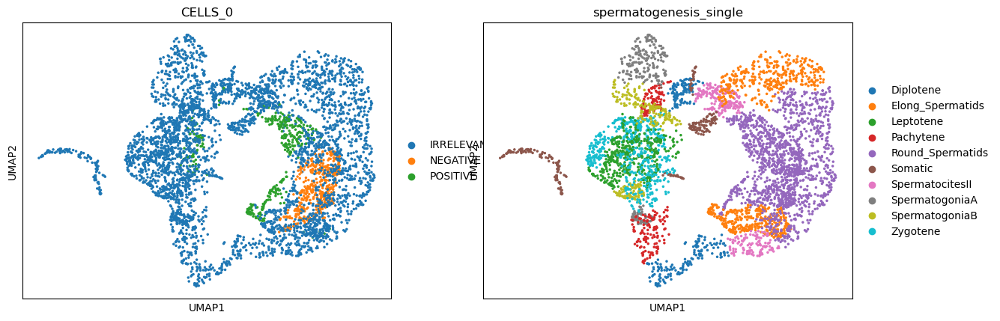

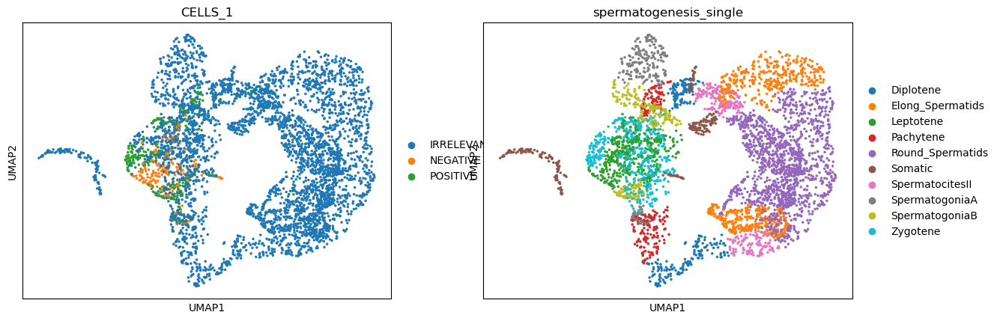

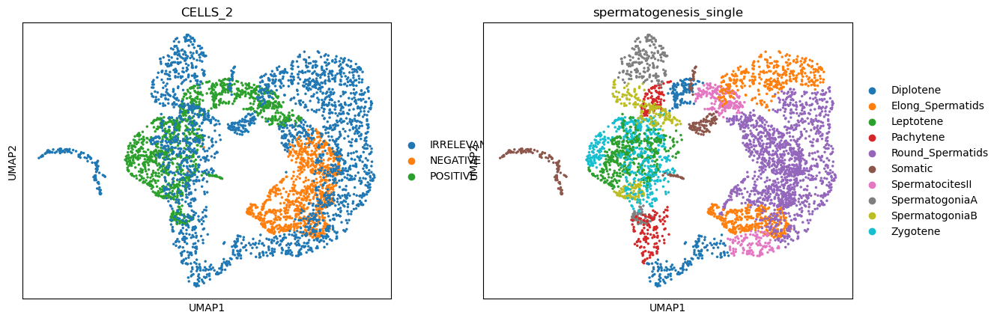

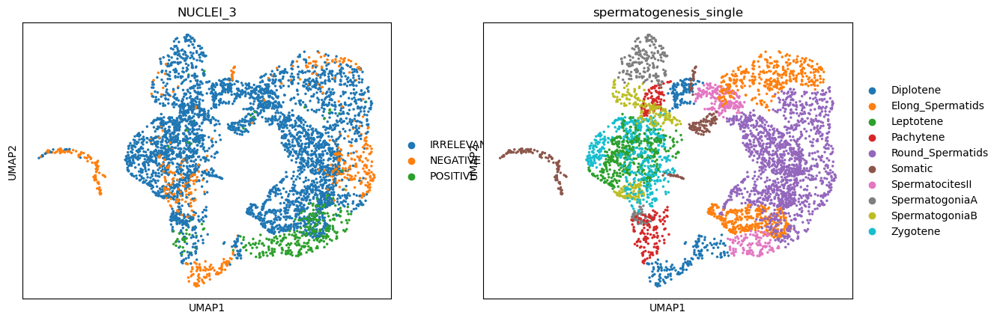

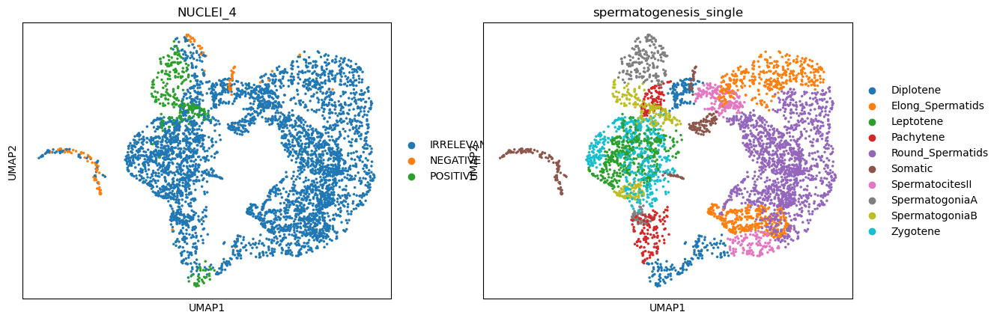

...

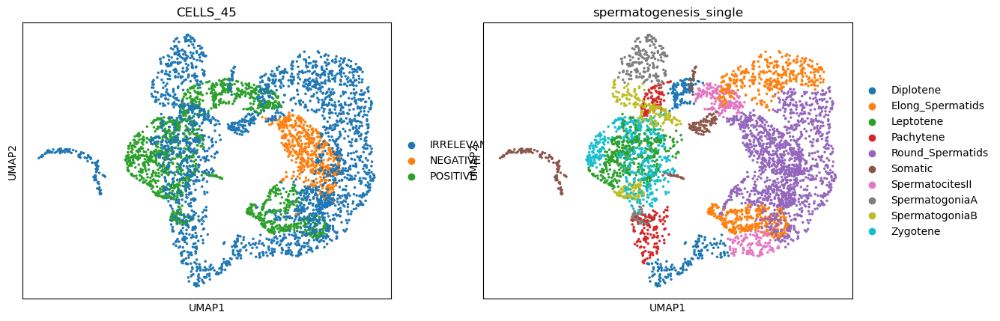

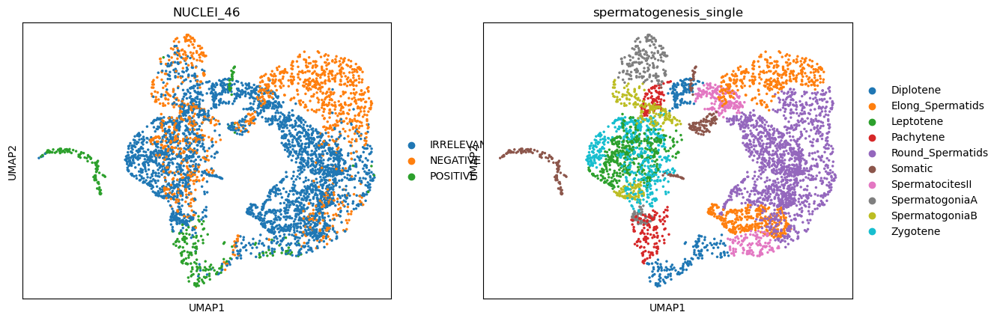

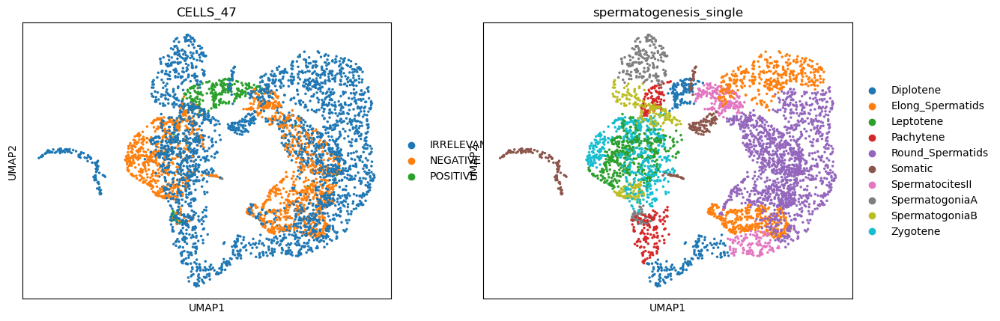

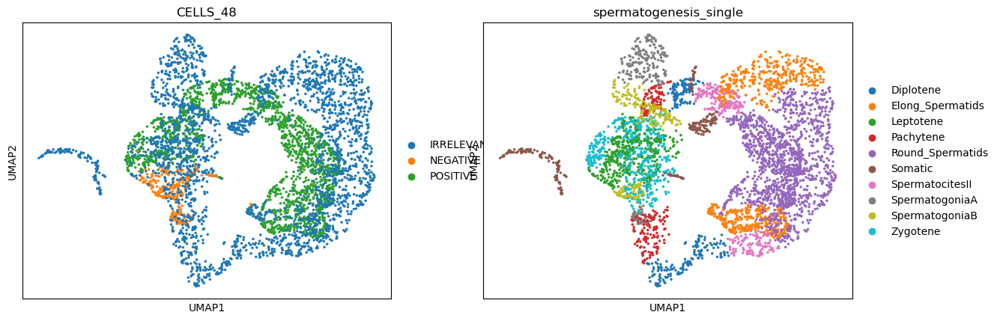

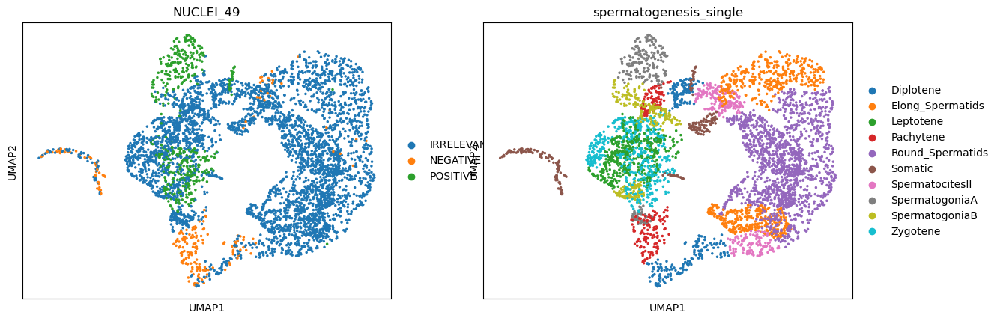

In [66]:
for i,j in zip(np.arange(50), refer_condition):
    sc.pl.umap(adata_sub, color=['sda_cell_relevant_C'+str(i),'spermatogenesis_single'], title=j+'_'+str(i))

In [91]:
for i in [3,5,7,18]:
    print('///////////')
    print(i)
    for j in np.array( adata_sub.var['sda_pos_high_C'+str(i)][adata_sub.var['sda_pos_high_C'+str(i)]].index):
        print(j)

///////////
3
AANAT
ADGB
AIM2
ALS2CR12
ANKUB1
ARMH1
BTBD16
C10H10orf67
C6H6orf118
C8H8orf89
C9H9orf135
CADM1
CAPS2
CCDC146
CCDC148
CCDC151
CCDC170
CCDC30
CCDC60
CDKL3
CFAP299
CFAP43
CFAP47
CFAP54
CFAP58
CFAP61
CFAP77
COPRS
COX6C
DLG4
DNAH6
DNAH9
DYNC2H1
EFCAB5
ENO4
ENTPD1
ERICH6B
EXTL2
FAM173A
FAM189A1
FAM221B
FHAD1
FRYL
FSIP1
GAS2
GLIS1
GPC6
GRM3
HEATR4
HS2ST1
HYDIN
IQCA1
IQCH
ITGBL1
JAKMIP2
KATNAL2
KCNT2
KCNU1
LDLRAD4
LEKR1
LOC100615653
LOC104001321
LOC104002083
LOC104005843
LOC104006130
LOC104007727
LOC104008129
LOC107966804
LOC107966977
LOC107967611
LOC107967940
LOC107967941
LOC107969218
LOC107970683
LOC107970827
LOC107970837
LOC107973427
LOC107973490
LOC107974278
LOC107975079
LOC107975981
LOC107976746
LOC112205578
LOC112208684
LOC457936
LOC740298
LRRC2
LRRC74B
LRRIQ1
LRRIQ3
LYRM4
MAPK10
MEF2A
MEI4
METTL15
MROH9
NRG1
PACRG
PALM
PPP1R3A
RAPGEF2
RBFOX1
RERG
RGL1
SEL1L2
SEM1
SH3BGRL2
SLC5A1
SLC9C2
SPATA13
SPINK2
TRIM5
TTC23L
TTC29
ULK4
WDPCP
WDR78
WWOX
ZFP2
///////////
5
ANKRD31
ANKS1

In [83]:
L2=np.array( adata_sub.var['sda_neg_high_C7'][adata_sub.var['sda_neg_high_C7']].index )

In [84]:
np.intersect1d(L1,L2)

array([], dtype=object)

In [85]:
L1

array(['ABHD3', 'ACTR2', 'ADAM32', 'ANO5', 'ARHGEF10', 'ARL13B', 'ASCC3',
       'ATP6AP1L', 'B3GNT5', 'C7H7orf57', 'CCDC110', 'CCDC146', 'CCDC60',
       'CD200R1', 'CDC25C', 'CDH26', 'CENPF', 'CFAP221', 'CFAP58',
       'CLEC16A', 'COLEC11', 'DNM3', 'ENTPD3', 'FAM117A', 'FAM126A',
       'FBXO25', 'FLYWCH1', 'FNIP2', 'GLIPR1L1', 'GP6', 'GPATCH2', 'GRK3',
       'GZMA', 'HDAC9', 'HMGA2', 'IFT74', 'INTS6', 'IQUB', 'KCNG3',
       'KIF14', 'KIF19', 'LCORL', 'LIPI', 'LOC100610891', 'LOC101057197',
       'LOC101058133', 'LOC104001487', 'LOC104004812', 'LOC104004911',
       'LOC104006140', 'LOC104006383', 'LOC104006755', 'LOC104006974',
       'LOC107966696', 'LOC107967592', 'LOC107967660', 'LOC107967662',
       'LOC107968973', 'LOC107969217', 'LOC107971840', 'LOC107973643',
       'LOC107974333', 'LOC107974487', 'LOC107974629', 'LOC107974739',
       'LOC107974785', 'LOC107975161', 'LOC107976644', 'LOC107976736',
       'LOC107976932', 'LOC112204111', 'LOC112204146', 'LOC112205594',
  

In [86]:
L2

array(['AIM2', 'ANKUB1', 'ANO3', 'ASXL3', 'ATP10A', 'ATP1A4',
       'C10H10orf90', 'C11H11orf97', 'C12H12orf71', 'C4H4orf45',
       'C4H4orf47', 'C8H8orf89', 'CCDC192', 'CCDC96', 'CDCP1', 'CFAP100',
       'CIB4', 'CNBD1', 'COLGALT1', 'CPA6', 'CUBN', 'CYP2C8', 'DDC',
       'DNAH9', 'ENOX1', 'EPB41L2', 'EPHA6', 'ERC1', 'ERICH3', 'ERICH6B',
       'FAM189A1', 'FOXN3', 'FRMD4B', 'GABRG1', 'GMDS', 'GOLGA6L2',
       'HMCN2', 'IGSF21', 'ITGB8', 'LDLRAD4', 'LOC100610326',
       'LOC101058385', 'LOC104001321', 'LOC104002083', 'LOC104002419',
       'LOC104005668', 'LOC104005843', 'LOC104006195', 'LOC104007631',
       'LOC107966134', 'LOC107966794', 'LOC107967036', 'LOC107967234',
       'LOC107967610', 'LOC107967611', 'LOC107967803', 'LOC107967945',
       'LOC107968862', 'LOC107969327', 'LOC107969947', 'LOC107970339',
       'LOC107970367', 'LOC107970525', 'LOC107970683', 'LOC107970702',
       'LOC107970867', 'LOC107971609', 'LOC107974166', 'LOC107974706',
       'LOC107975322', 'LOC10